In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. 데이터 로드 (파일 경로 확인 필요)
file_path = "weather_filtered_7days.csv"

# 인코딩 문제 방지를 위해 try-except 구문 사용
try:
    df = pd.read_csv(file_path, encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='utf-8')

# 2. 성능 평가 함수 정의
def calculate_metrics(group):
    # 계산에 필요한 데이터가 모두 있는지 확인하고, 하나라도 없으면 해당 행 제외
    valid_data = group.dropna(subset=['Max_Temp', 'Min_Temp', 'Target_Max', 'Target_Min'])
    
    # 데이터가 없으면 NaN 반환
    if len(valid_data) == 0:
        return pd.Series({
            'Max_MAE': np.nan, 'Max_MSE': np.nan, 'Max_RMSE': np.nan,
            'Min_MAE': np.nan, 'Min_MSE': np.nan, 'Min_RMSE': np.nan
        })

    # --- 최고 기온 (Max Temp) 평가 ---
    max_mae = mean_absolute_error(valid_data['Target_Max'], valid_data['Max_Temp'])
    max_mse = mean_squared_error(valid_data['Target_Max'], valid_data['Max_Temp'])
    max_rmse = np.sqrt(max_mse) # RMSE는 MSE의 제곱근

    # --- 최저 기온 (Min Temp) 평가 ---
    min_mae = mean_absolute_error(valid_data['Target_Min'], valid_data['Min_Temp'])
    min_mse = mean_squared_error(valid_data['Target_Min'], valid_data['Min_Temp'])
    min_rmse = np.sqrt(min_mse)

    return pd.Series({
        'Max_MAE': max_mae, 'Max_MSE': max_mse, 'Max_RMSE': max_rmse,
        'Min_MAE': min_mae, 'Min_MSE': min_mse, 'Min_RMSE': min_rmse
    })

# 3. Site별로 그룹화하여 성능 평가 수행
metrics_df = df.groupby('Site').apply(calculate_metrics).reset_index()

# 4. 결과 출력 및 저장
metrics_df = metrics_df.round(3) # 소수점 3자리까지 반올림
print("--- 사이트별 예측 성능 평가 결과 (MAE, MSE, RMSE) ---")


# 결과를 CSV 파일로 저장
metrics_df.to_csv("weather_performance_metrics.csv", index=False, encoding='cp949')
print("\n평가 결과가 'weather_performance_metrics.csv'로 저장되었습니다.")

metrics_df

--- 사이트별 예측 성능 평가 결과 (MAE, MSE, RMSE) ---

평가 결과가 'weather_performance_metrics.csv'로 저장되었습니다.


C:\Users\5174k\AppData\Local\Temp\ipykernel_27804\3031372111.py:42: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_df = df.groupby('Site').apply(calculate_metrics).reset_index()


,Site,Max_MAE,Max_MSE,Max_RMSE,Min_MAE,Min_MSE,Min_RMSE
0,기상청,1.969,6.740,2.596,1.479,4.625,2.151
1,더웨더네트워크,2.506,8.988,2.998,2.759,12.711,3.565
2,메테오블루,1.505,3.720,1.929,1.161,2.796,1.672
3,아큐웨더,1.646,5.667,2.380,3.115,16.719,4.089
4,웨더뉴스,2.042,6.854,2.618,1.458,4.458,2.111
5,웨더채널,1.476,3.690,1.921,3.274,17.560,4.190


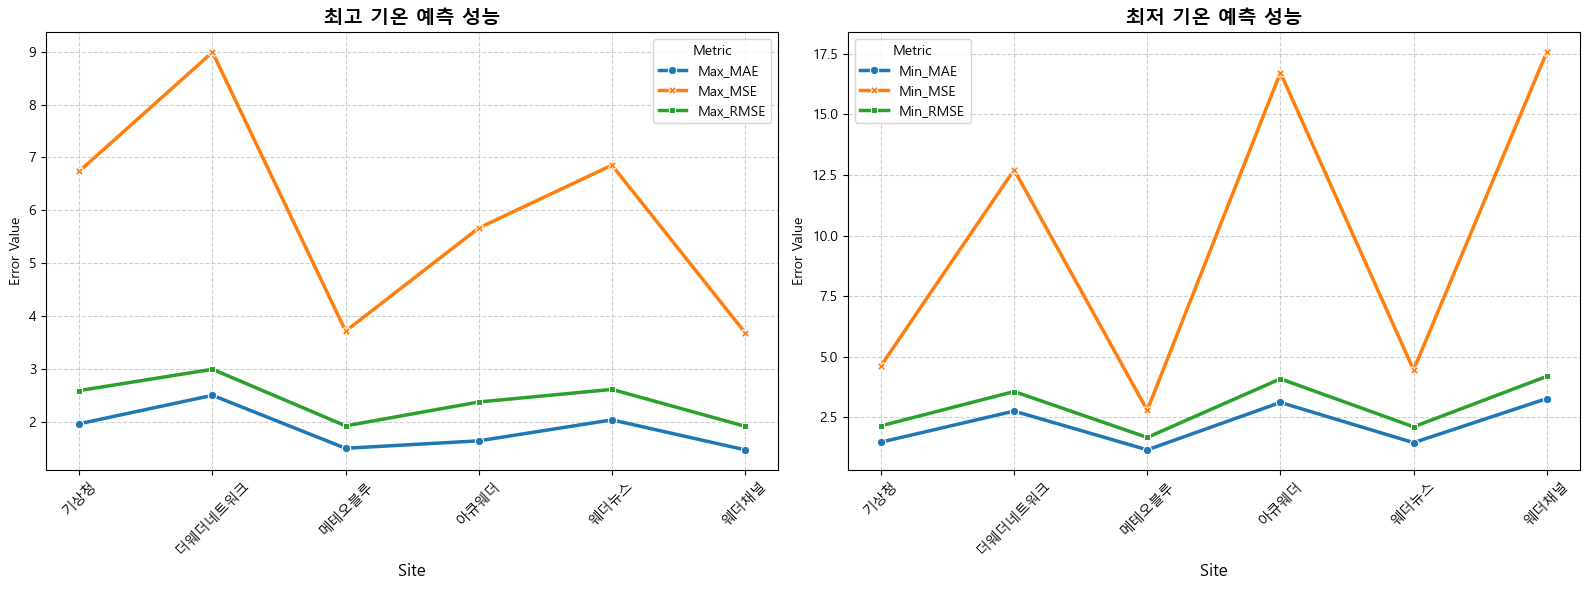

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------
# [설정] 한글 폰트가 깨진다면 아래 주석을 풀고 실행하세요 (Windows 기준)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
# -------------------------------------------------------

# 1. 데이터 로드 (방금 저장한 CSV 파일 읽기)
try:
    df = pd.read_csv("weather_performance_metrics.csv", encoding='cp949')
except:
    df = pd.read_csv("weather_performance_metrics.csv", encoding='utf-8')

# 2. 시각화를 위해 데이터 형태 변환 (Wide -> Long)
# 최고 기온(Max) 관련 지표만 추출하여 세로로 길게 변환
df_max = df[['Site', 'Max_MAE', 'Max_MSE', 'Max_RMSE']].melt(
    id_vars='Site', var_name='Metric', value_name='Error Value'
)
# 최저 기온(Min) 관련 지표만 추출
df_min = df[['Site', 'Min_MAE', 'Min_MSE', 'Min_RMSE']].melt(
    id_vars='Site', var_name='Metric', value_name='Error Value'
)

# 3. 꺾은선 그래프 그리기
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (왼쪽) 최고 기온 예측 성능 그래프
sns.lineplot(
    data=df_max, x='Site', y='Error Value', hue='Metric', style='Metric',
    markers=True, dashes=False, linewidth=2.5, ax=axes[0]
)
axes[0].set_title('최고 기온 예측 성능', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Site', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.6)

# (오른쪽) 최저 기온 예측 성능 그래프
sns.lineplot(
    data=df_min, x='Site', y='Error Value', hue='Metric', style='Metric',
    markers=True, dashes=False, linewidth=2.5, ax=axes[1]
)
axes[1].set_title('최저 기온 예측 성능', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Site', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('temp_prediction_performance.png')
plt.show()

In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. 데이터 로드 (인코딩 자동 처리)
file_path = "weather_filtered_7days.csv"
try:
    df = pd.read_csv(file_path, encoding='utf-8')
except UnicodeDecodeError:
    try:
        df = pd.read_csv(file_path, encoding='cp949')
    except:
        df = pd.read_csv(file_path, encoding='euc-kr')

# 2. [중요] 최신 예측값만 필터링 (정확한 평가를 위해)
def filter_latest_predictions(df):
    def parse_date_str(date_str):
        try:
            month, day = date_str.replace('월', '').replace('일', '').split()
            return f"{int(month):02d}-{int(day):02d}"
        except:
            return date_str
            
    df['Measure_Date_Sort'] = df['Measure_Date'].apply(parse_date_str)
    # Site, Target_Date별로 정렬 후 가장 최근(Measure_Date가 늦은) 것만 선택
    df_sorted = df.sort_values(by=['Site', 'Target_Date', 'Measure_Date_Sort'], ascending=[True, True, False])
    df_latest = df_sorted.drop_duplicates(subset=['Site', 'Target_Date'], keep='first')
    return df_latest

df_latest = filter_latest_predictions(df)

# 3. 데이터 합치기: Max와 Min을 'Temp'라는 하나의 데이터로 통합
# Max Temp 데이터 추출
df_max = df_latest[['Site', 'Target_Date', 'Max_Temp', 'Target_Max']].copy()
df_max.columns = ['Site', 'Target_Date', 'Pred', 'Actual']
df_max['Type'] = 'Max' # 구분용 (필요시 사용)

# Min Temp 데이터 추출
df_min = df_latest[['Site', 'Target_Date', 'Min_Temp', 'Target_Min']].copy()
df_min.columns = ['Site', 'Target_Date', 'Pred', 'Actual']
df_min['Type'] = 'Min'

# 위아래로 합치기 (Concatenate)
df_combined = pd.concat([df_max, df_min], axis=0)
df_combined.dropna(subset=['Pred', 'Actual'], inplace=True)

# 4. 통합 성능 평가 함수 정의
def calculate_total_metrics(group):
    mae = mean_absolute_error(group['Actual'], group['Pred'])
    mse = mean_squared_error(group['Actual'], group['Pred'])
    rmse = np.sqrt(mse)
    
    return pd.Series({
        'Total_MAE': mae,
        'Total_MSE': mse,
        'Total_RMSE': rmse
    })

# 5. Site별로 그룹화하여 통합 성능 평가 수행
metrics_total = df_combined.groupby('Site').apply(calculate_total_metrics).reset_index()
metrics_total = metrics_total.round(3)



# 결과를 CSV 파일로 저장
output_file = "weather_performance_total_metrics.csv"
metrics_total.to_csv(output_file, index=False, encoding='cp949')
print(f"\n통합 평가 결과가 '{output_file}'로 저장되었습니다.")

print("--- 7일 예측 사이트별 통합(최고+최저) 예측 성능 평가 결과 ---")
metrics_total


통합 평가 결과가 'weather_performance_total_metrics.csv'로 저장되었습니다.
--- 7일 예측 사이트별 통합(최고+최저) 예측 성능 평가 결과 ---


C:\Users\5174k\AppData\Local\Temp\ipykernel_27804\2042617434.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_total = df_combined.groupby('Site').apply(calculate_total_metrics).reset_index()


,Site,Total_MAE,Total_MSE,Total_RMSE
0,기상청,1.289,6.500,2.550
1,더웨더네트워크,2.816,11.763,3.430
2,메테오블루,1.026,3.447,1.857
3,아큐웨더,2.184,10.447,3.232
4,웨더뉴스,1.500,6.553,2.560
5,웨더채널,2.417,10.528,3.245


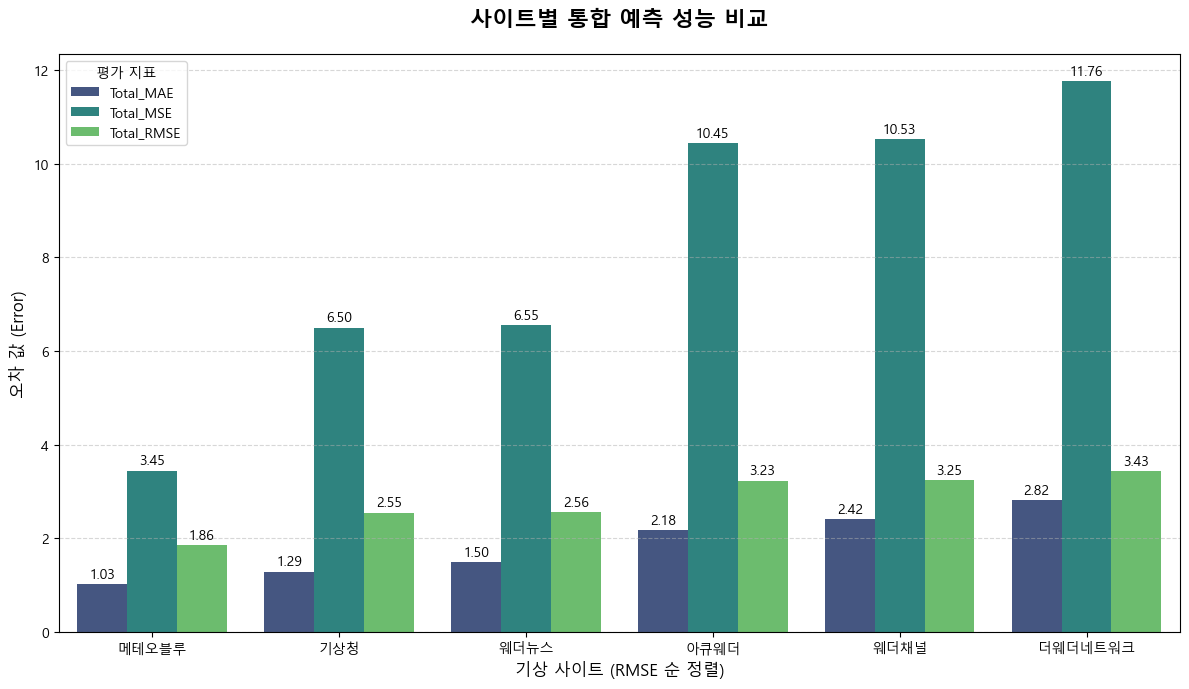

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------
# [설정] 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rc('font', family='Malgun Gothic') 
plt.rc('axes', unicode_minus=False)
# -------------------------------------------------------

# 1. 데이터 로드 (방금 저장한 파일)
try:
    df = pd.read_csv("weather_performance_total_metrics.csv", encoding='cp949')
except:
    df = pd.read_csv("weather_performance_total_metrics.csv", encoding='utf-8')

# 2. 시각화 준비: RMSE 기준 오름차순 정렬 (성능 좋은 순서대로 보기 위해)
df_sorted = df.sort_values(by='Total_RMSE', ascending=True)

# 3. 데이터 형태 변환 (Wide -> Long) for Seaborn
df_melt = df_sorted.melt(id_vars='Site', var_name='Metric', value_name='Error Value')

# 4. 막대그래프 그리기
plt.figure(figsize=(12, 7))

# 막대 생성
ax = sns.barplot(
    data=df_melt, 
    x='Site', 
    y='Error Value', 
    hue='Metric', 
    palette='viridis' # 색상 테마 (viridis, coolwarm, deep 등 변경 가능)
)

# 5. 디자인 다듬기
plt.title('사이트별 통합 예측 성능 비교', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('기상 사이트 (RMSE 순 정렬)', fontsize=12)
plt.ylabel('오차 값 (Error)', fontsize=12)
plt.legend(title='평가 지표')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 6. 막대 위에 수치 표시 (Annotate)
for p in ax.patches:
    if p.get_height() > 0:  # 데이터가 있는 경우만 표시
        ax.annotate(
            f'{p.get_height():.2f}', 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='center', 
            xytext=(0, 7), 
            textcoords='offset points',
            fontsize=10, 
            color='black'
        )

plt.tight_layout()
plt.savefig('total_predict.png')
plt.show()

In [5]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. 데이터 로드 (7일치 필터링된 파일 또는 원본 파일)
file_path = "weather_filtered_7days.csv"

# 인코딩 호환성을 위해 try-except 구문 사용
try:
    df = pd.read_csv(file_path, encoding='cp949')
except UnicodeDecodeError:
    try:
        df = pd.read_csv(file_path, encoding='utf-8')
    except:
        df = pd.read_csv(file_path, encoding='euc-kr')

# 2. 날짜 파싱 함수 (한글 날짜 -> Python 날짜 객체 변환)
def parse_korean_date(date_str):
    try:
        # "11월 12일" 형식 처리
        month, day = date_str.replace('월', '').replace('일', '').split()
        # 연도는 2024년으로 설정 (데이터 분석용)
        return datetime(2024, int(month), int(day))
    except:
        return None

# 날짜 컬럼 변환 적용
df['Measure_Date_DT'] = df['Measure_Date'].apply(parse_korean_date)
df['Target_Date_DT'] = df['Target_Date'].apply(parse_korean_date)

# 3. Lead Time (예측 기간 차이) 계산
# Lead Time = 예측 대상 날짜 - 실제 측정한 날짜
df['Lead_Time'] = (df['Target_Date_DT'] - df['Measure_Date_DT']).dt.days

# 4. [핵심] 필터링: 1일 ~ 3일 전 예측 (3일치)
# 조건: 1 <= 차이 <= 3
filtered_df = df[(df['Lead_Time'] >= 1) & (df['Lead_Time'] <= 3)].copy()

print(f"전체 데이터 개수: {len(df)}개 -> 3일치 필터링 후: {len(filtered_df)}개")

# 5. 성능 평가 함수 정의 (MAE, MSE, RMSE)
def calculate_metrics(group):
    # 유효한 데이터만 남기기 (NaN 제거)
    valid_data = group.dropna(subset=['Max_Temp', 'Min_Temp', 'Target_Max', 'Target_Min'])
    
    if len(valid_data) == 0:
        return pd.Series({
            'Max_MAE': np.nan, 'Max_MSE': np.nan, 'Max_RMSE': np.nan,
            'Min_MAE': np.nan, 'Min_MSE': np.nan, 'Min_RMSE': np.nan
        })

    # 최고 기온 (Max Temp) 평가
    max_mae = mean_absolute_error(valid_data['Target_Max'], valid_data['Max_Temp'])
    max_mse = mean_squared_error(valid_data['Target_Max'], valid_data['Max_Temp'])
    max_rmse = np.sqrt(max_mse)

    # 최저 기온 (Min Temp) 평가
    min_mae = mean_absolute_error(valid_data['Target_Min'], valid_data['Min_Temp'])
    min_mse = mean_squared_error(valid_data['Target_Min'], valid_data['Min_Temp'])
    min_rmse = np.sqrt(min_mse)

    return pd.Series({
        'Max_MAE': max_mae, 'Max_MSE': max_mse, 'Max_RMSE': max_rmse,
        'Min_MAE': min_mae, 'Min_MSE': min_mse, 'Min_RMSE': min_rmse
    })

# 6. Site별 평가 수행 및 결과 저장
metrics_df = filtered_df.groupby('Site').apply(calculate_metrics).reset_index()
metrics_df = metrics_df.round(3)



# 결과를 CSV 파일로 저장
output_file = "weather_metrics_3days_before.csv"
metrics_df.to_csv(output_file, index=False, encoding='cp949')
print(f"\n계산 결과가 '{output_file}'로 저장되었습니다.")

print("\n--- 사이트별 예측 성능 평가 결과 (3일치: D-3 ~ D-1) ---")
metrics_df

전체 데이터 개수: 548개 -> 3일치 필터링 후: 214개

계산 결과가 'weather_metrics_3days_before.csv'로 저장되었습니다.

--- 사이트별 예측 성능 평가 결과 (3일치: D-3 ~ D-1) ---


C:\Users\5174k\AppData\Local\Temp\ipykernel_27804\3131418846.py:69: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_df = filtered_df.groupby('Site').apply(calculate_metrics).reset_index()


,Site,Max_MAE,Max_MSE,Max_RMSE,Min_MAE,Min_MSE,Min_RMSE
0,기상청,1.750,4.583,2.141,1.028,2.194,1.481
1,더웨더네트워크,2.265,6.735,2.595,2.412,8.235,2.870
2,메테오블루,1.611,3.556,1.886,0.639,0.972,0.986
3,아큐웨더,1.194,2.861,1.691,2.861,10.750,3.279
4,웨더뉴스,1.750,4.694,2.167,0.972,1.917,1.384
5,웨더채널,1.194,2.472,1.572,2.833,11.056,3.325


In [6]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. 데이터 로드 및 3일치 필터링
file_path = "weather_filtered_7days.csv"
try:
    df = pd.read_csv(file_path, encoding='cp949')
except:
    df = pd.read_csv(file_path, encoding='utf-8')

def filter_3_day_lead_time(df):
    def parse_korean_date(date_str):
        try:
            month, day = date_str.replace('월', '').replace('일', '').split()
            return datetime(2024, int(month), int(day))
        except:
            return None

    df['Measure_Date_DT'] = df['Measure_Date'].apply(parse_korean_date)
    df['Target_Date_DT'] = df['Target_Date'].apply(parse_korean_date)
    df['Lead_Time'] = (df['Target_Date_DT'] - df['Measure_Date_DT']).dt.days

    # 필터링: 1일 <= 차이 <= 3일
    filtered_df = df[(df['Lead_Time'] >= 1) & (df['Lead_Time'] <= 3)].copy()
    return filtered_df

df_3day = filter_3_day_lead_time(df)

# 2. 데이터 합치기: Max와 Min을 하나의 'Pred'/'Actual' 열로 통합
# 최고 기온 데이터
df_max = df_3day[['Site', 'Target_Date', 'Max_Temp', 'Target_Max']].copy()
df_max.columns = ['Site', 'Target_Date', 'Pred', 'Actual']

# 최저 기온 데이터
df_min = df_3day[['Site', 'Target_Date', 'Min_Temp', 'Target_Min']].copy()
df_min.columns = ['Site', 'Target_Date', 'Pred', 'Actual']

# 위아래로 합치기
df_combined = pd.concat([df_max, df_min], axis=0)
df_combined.dropna(subset=['Pred', 'Actual'], inplace=True)

# 3. 통합 성능 평가 함수 (Max+Min 오차 합산)
def calculate_total_metrics(group):
    mae = mean_absolute_error(group['Actual'], group['Pred'])
    mse = mean_squared_error(group['Actual'], group['Pred'])
    rmse = np.sqrt(mse)
    
    return pd.Series({
        'Total_MAE': mae,
        'Total_MSE': mse,
        'Total_RMSE': rmse
    })

# 4. Site별로 그룹화하여 통합 성능 평가 수행
metrics_total = df_combined.groupby('Site').apply(calculate_total_metrics).reset_index()
metrics_total = metrics_total.round(3)


# 5. CSV 저장
output_file = "weather_metrics_3days_total.csv"
metrics_total.to_csv(output_file, index=False, encoding='cp949')

print("--- 사이트별 통합 예측 성능 결과 (3일치: D-3 ~ D-1) ---")
metrics_total


--- 사이트별 통합 예측 성능 결과 (3일치: D-3 ~ D-1) ---


C:\Users\5174k\AppData\Local\Temp\ipykernel_27804\2313212406.py:57: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_total = df_combined.groupby('Site').apply(calculate_total_metrics).reset_index()


,Site,Total_MAE,Total_MSE,Total_RMSE
0,기상청,1.389,3.389,1.841
1,더웨더네트워크,2.338,7.485,2.736
2,메테오블루,1.125,2.264,1.505
3,아큐웨더,2.028,6.806,2.609
4,웨더뉴스,1.361,3.306,1.818
5,웨더채널,2.014,6.764,2.601


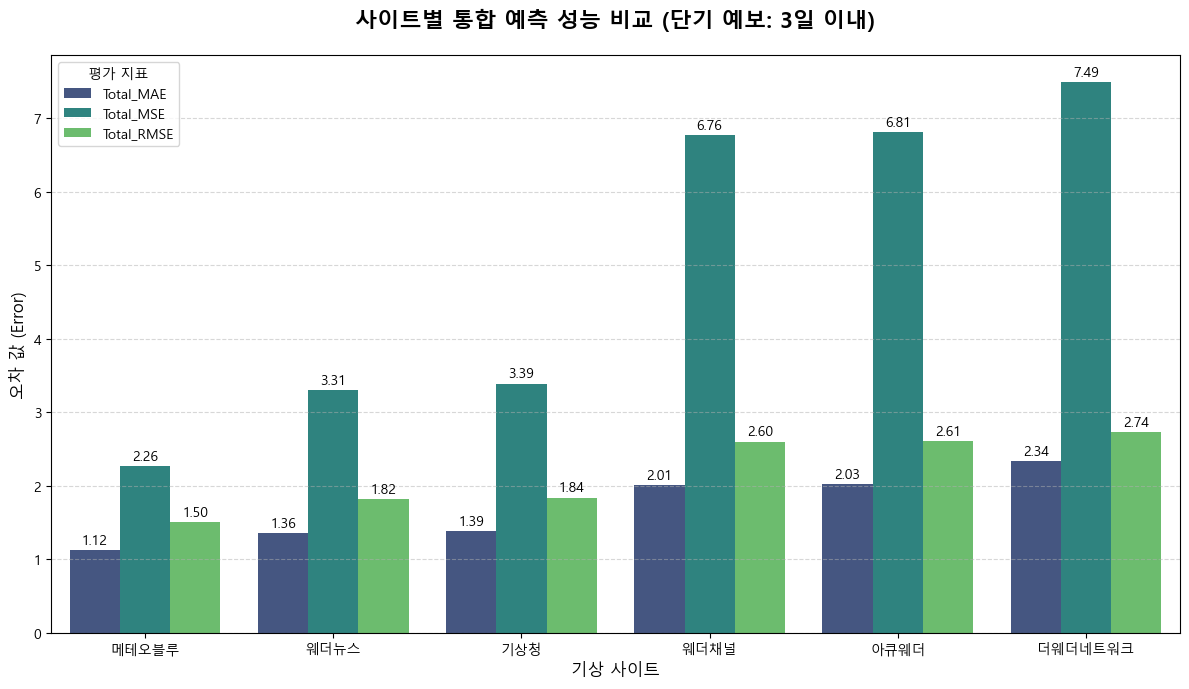

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------
# [설정] 한글 폰트 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
# -------------------------------------------------------

# 1. 데이터 로드 (방금 생성한 3일치 데이터 파일)
try:
    df = pd.read_csv("weather_metrics_3days_total.csv", encoding='cp949')
except:
    df = pd.read_csv("weather_metrics_3days_total.csv", encoding='utf-8')

# 2. 시각화 준비: RMSE 기준 오름차순 정렬 (성능 좋은 순서대로)
df_sorted = df.sort_values(by='Total_RMSE', ascending=True)

# 3. 데이터 형태 변환 (Wide -> Long) for Seaborn
df_melt = df_sorted.melt(id_vars='Site', var_name='Metric', value_name='Value')

# 4. 막대그래프 그리기
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=df_melt, 
    x='Site', 
    y='Value', 
    hue='Metric', 
    palette='viridis'  # 색상 테마
)

# 5. 디자인 (제목 깔끔하게 수정)
plt.title('사이트별 통합 예측 성능 비교 (단기 예보: 3일 이내)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('기상 사이트', fontsize=12)
plt.ylabel('오차 값 (Error)', fontsize=12)
plt.legend(title='평가 지표')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 6. 막대 위에 수치 표시 (소수점 2자리)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f'{p.get_height():.2f}', 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='center', 
            xytext=(0, 7), 
            textcoords='offset points',
            fontsize=10, 
            color='black'
        )

plt.tight_layout()
plt.savefig('3days_pred.png')
plt.show()

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 데이터 로드 및 전처리
try:
    df = pd.read_csv('weather_filtered_7days.csv', encoding='cp949')
except:
    df = pd.read_csv('weather_filtered_7days.csv', encoding='utf-8')

df['Max_Error'] = df['Max_Temp'] - df['Target_Max']
df['Min_Error'] = df['Min_Temp'] - df['Target_Min']
X = pd.get_dummies(df['Site'])

# --- 최고 기온 오차 모델 ---
y_max = df['Max_Error']
X_train, X_test, y_train, y_test = train_test_split(X, y_max, test_size=0.2, random_state=42)
model_max = LinearRegression().fit(X_train, y_train)
y_pred = model_max.predict(X_test)

print("--- 최고 기온 오차 모델 평가 ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# --- 최저 기온 오차 모델 ---
y_min = df['Min_Error']
X_train, X_test, y_train, y_test = train_test_split(X, y_min, test_size=0.2, random_state=42)
model_min = LinearRegression().fit(X_train, y_train)
y_pred = model_min.predict(X_test)

print("\n--- 최저 기온 오차 모델 평가 ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

--- 최고 기온 오차 모델 평가 ---
MAE: 1.3029
MSE: 3.1450
RMSE: 1.7734

--- 최저 기온 오차 모델 평가 ---
MAE: 1.9772
MSE: 7.5484
RMSE: 2.7474


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. 데이터 로드
df = pd.read_csv('weather_filtered_7days.csv', encoding='cp949')

# 2. 데이터 전처리 (최고/최저 오차 통합)
# 오차 = 예보 - 실제
df['Max_Error'] = df['Max_Temp'] - df['Target_Max']
df['Min_Error'] = df['Min_Temp'] - df['Target_Min']

# 통합 데이터 프레임 생성 (Stacking)
df_max = df[['Site', 'Max_Error']].rename(columns={'Max_Error': 'Error'})
df_min = df[['Site', 'Min_Error']].rename(columns={'Min_Error': 'Error'})
df_combined = pd.concat([df_max, df_min], axis=0).reset_index(drop=True)

# 3. 모델 학습을 위한 데이터 분할 (80% 학습, 20% 평가)
X = pd.get_dummies(df_combined['Site']) # 원-핫 인코딩
y = df_combined['Error']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 선형회귀 모델 학습 
# fit_intercept=False: 각 사이트의 계수(Coefficient)가 곧 해당 사이트의 평균 편향(Bias)이 되도록 함
model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)

# 5. [결과 1] 전체 통합 모델 평가 (Test Set)
y_pred = model.predict(X_test)

total_mae = mean_absolute_error(y_test, y_pred)
total_mse = mean_squared_error(y_test, y_pred)
total_rmse = np.sqrt(total_mse)

print("=== [1] 통합 모델 평가 결과 (Test Set 20%) ===")
print(f"MAE  (평균 절대 오차) : {total_mae:.4f}")
print(f"MSE  (평균 제곱 오차) : {total_mse:.4f}")
print(f"RMSE (평균 제곱근 오차): {total_rmse:.4f}")
print("-" * 50)

# 6. [결과 2] 사이트별 상세 지표 비교
# 각 사이트의 실제 오차 데이터를 기반으로 계산 (전체 데이터 사용)
site_stats = df_combined.groupby('Site')['Error'].agg([
    ('Bias (Mean Error)', 'mean'),                # 평균 편향 (실제보다 얼마나 높게/낮게 잡는지)
    ('MAE', lambda x: np.mean(np.abs(x))),        # 절대 오차 평균
    ('MSE', lambda x: np.mean(x**2)),             # 제곱 오차 평균
    ('RMSE', lambda x: np.sqrt(np.mean(x**2)))    # 제곱근 오차 평균
])

# 모델이 학습한 가중치(Coefficient)도 비교를 위해 추가
model_bias = pd.Series(model.coef_, index=X.columns, name='Model Coef (Learned Bias)')
final_comparison = pd.concat([site_stats, model_bias], axis=1)

print("\n=== [2] 사이트별 상세 지표 비교 ===")
# 보기 좋게 소수점 4자리 반올림
final_comparison.round(4)

=== [1] 통합 모델 평가 결과 (Test Set 20%) ===
MAE  (평균 절대 오차) : 1.8098
MSE  (평균 제곱 오차) : 5.7211
RMSE (평균 제곱근 오차): 2.3919
--------------------------------------------------

=== [2] 사이트별 상세 지표 비교 ===


,Bias (Mean Error),MAE,MSE,RMSE,Model Coef (Learned Bias)
기상청,-1.2656,1.7240,5.6823,2.3838,-1.2649
더웨더네트워크,-1.4639,2.6325,10.8494,3.2938,-1.4000
메테오블루,-0.5376,1.3333,3.2581,1.8050,-0.6645
아큐웨더,-1.6615,2.3802,11.1927,3.3456,-1.7635
웨더뉴스,-1.2812,1.7500,5.6562,2.3783,-1.2436
웨더채널,-1.8988,2.3750,10.6250,3.2596,-1.7910


C:\Users\5174k\AppData\Local\Temp\ipykernel_27804\1445966588.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x='Site', y='RMSE', data=plot_df, palette='viridis')
C:\Users\5174k\AppData\Local\Temp\ipykernel_27804\1445966588.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='Site', y='MAE', data=plot_df, palette='viridis')


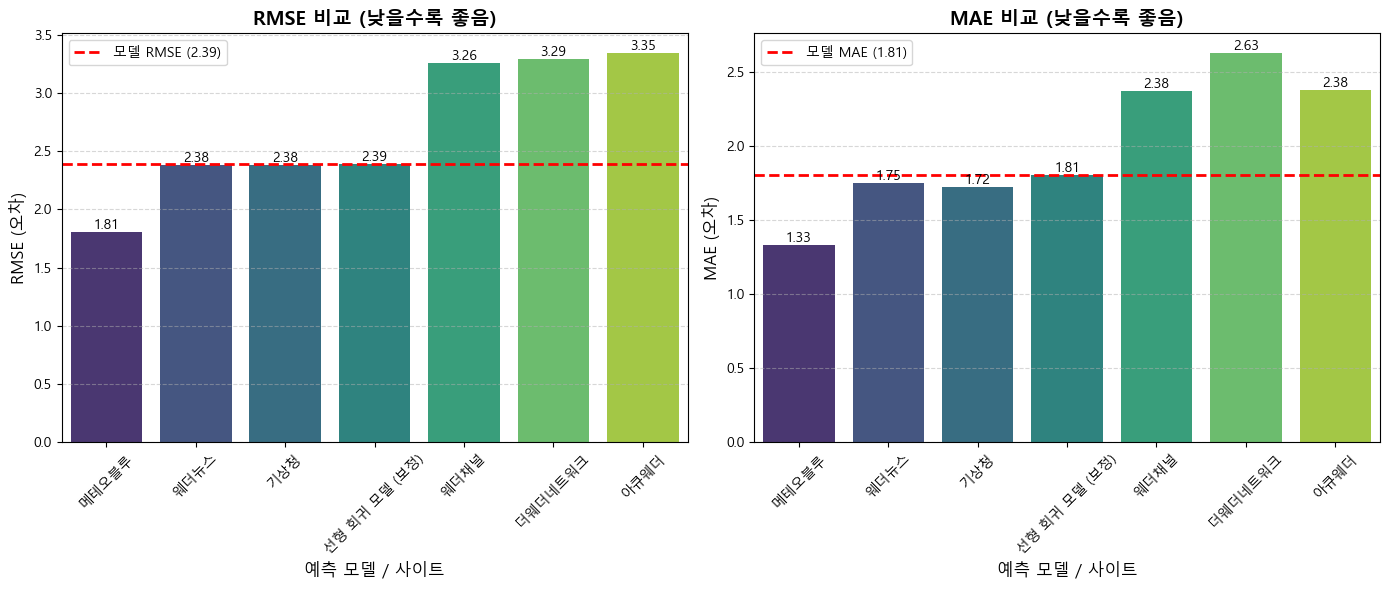

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -------------------------------------------------------
# [설정] 한글 폰트 설정 (사용하는 환경에 맞춰 주석을 풀어주세요!)
# Windows
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False) # 마이너스 기호 깨짐 방지
# -------------------------------------------------------

# 1. 데이터 로드
df = pd.read_csv('weather_filtered_7days.csv', encoding='cp949')

# 2. 오차 계산 및 데이터 통합 (Stacking)
df['Max_Error'] = df['Max_Temp'] - df['Target_Max']
df['Min_Error'] = df['Min_Temp'] - df['Target_Min']

# 최고/최저 오차를 세로로 길게 합침
df_max = df[['Site', 'Max_Error']].rename(columns={'Max_Error': 'Error'})
df_min = df[['Site', 'Min_Error']].rename(columns={'Min_Error': 'Error'})
df_combined = pd.concat([df_max, df_min], axis=0).reset_index(drop=True)

# 3. 모델 학습 (Linear Regression)
# 각 사이트를 Feature(변수)로 사용하기 위해 원-핫 인코딩
X = pd.get_dummies(df_combined['Site'])
y = df_combined['Error']

# 학습/평가 데이터 분리 (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 학습 (편향 학습을 위해 intercept 끔 -> 각 사이트 변수가 Bias 역할)
model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)

# 모델 성능 평가
y_pred = model.predict(X_test)
model_mae = mean_absolute_error(y_test, y_pred)
model_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# 4. 각 사이트별 실제 오차 지표 계산
site_stats = df_combined.groupby('Site')['Error'].agg([
    lambda x: np.mean(np.abs(x)),       # MAE
    lambda x: np.sqrt(np.mean(x**2))    # RMSE
]).reset_index()
site_stats.columns = ['Site', 'MAE', 'RMSE']

# 5. 시각화 데이터 준비
# '선형 회귀 모델' 결과를 새로운 행으로 추가
new_row = pd.DataFrame({
    'Site': ['선형 회귀 모델 (보정)'],
    'MAE': [model_mae],
    'RMSE': [model_rmse]
})
plot_df = pd.concat([site_stats, new_row], axis=0).reset_index(drop=True)

# RMSE 기준으로 정렬 (성능 좋은 순서)
plot_df = plot_df.sort_values(by='RMSE')

# 6. 그래프 그리기 (한글 라벨 적용)
plt.figure(figsize=(14, 6))

# (1) RMSE 그래프
plt.subplot(1, 2, 1)
ax1 = sns.barplot(x='Site', y='RMSE', data=plot_df, palette='viridis')
# 모델 성능 기준선 표시
plt.axhline(y=model_rmse, color='r', linestyle='--', linewidth=2, label=f'모델 RMSE ({model_rmse:.2f})')

plt.title('RMSE 비교 (낮을수록 좋음)', fontsize=14, fontweight='bold')
plt.xlabel('예측 모델 / 사이트', fontsize=12)
plt.ylabel('RMSE (오차)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 막대 위에 수치 표시
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=10, color='black')

# (2) MAE 그래프
plt.subplot(1, 2, 2)
ax2 = sns.barplot(x='Site', y='MAE', data=plot_df, palette='viridis')
# 모델 성능 기준선 표시
plt.axhline(y=model_mae, color='r', linestyle='--', linewidth=2, label=f'모델 MAE ({model_mae:.2f})')

plt.title('MAE 비교 (낮을수록 좋음)', fontsize=14, fontweight='bold')
plt.xlabel('예측 모델 / 사이트', fontsize=12)
plt.ylabel('MAE (오차)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 막대 위에 수치 표시
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.2f}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()

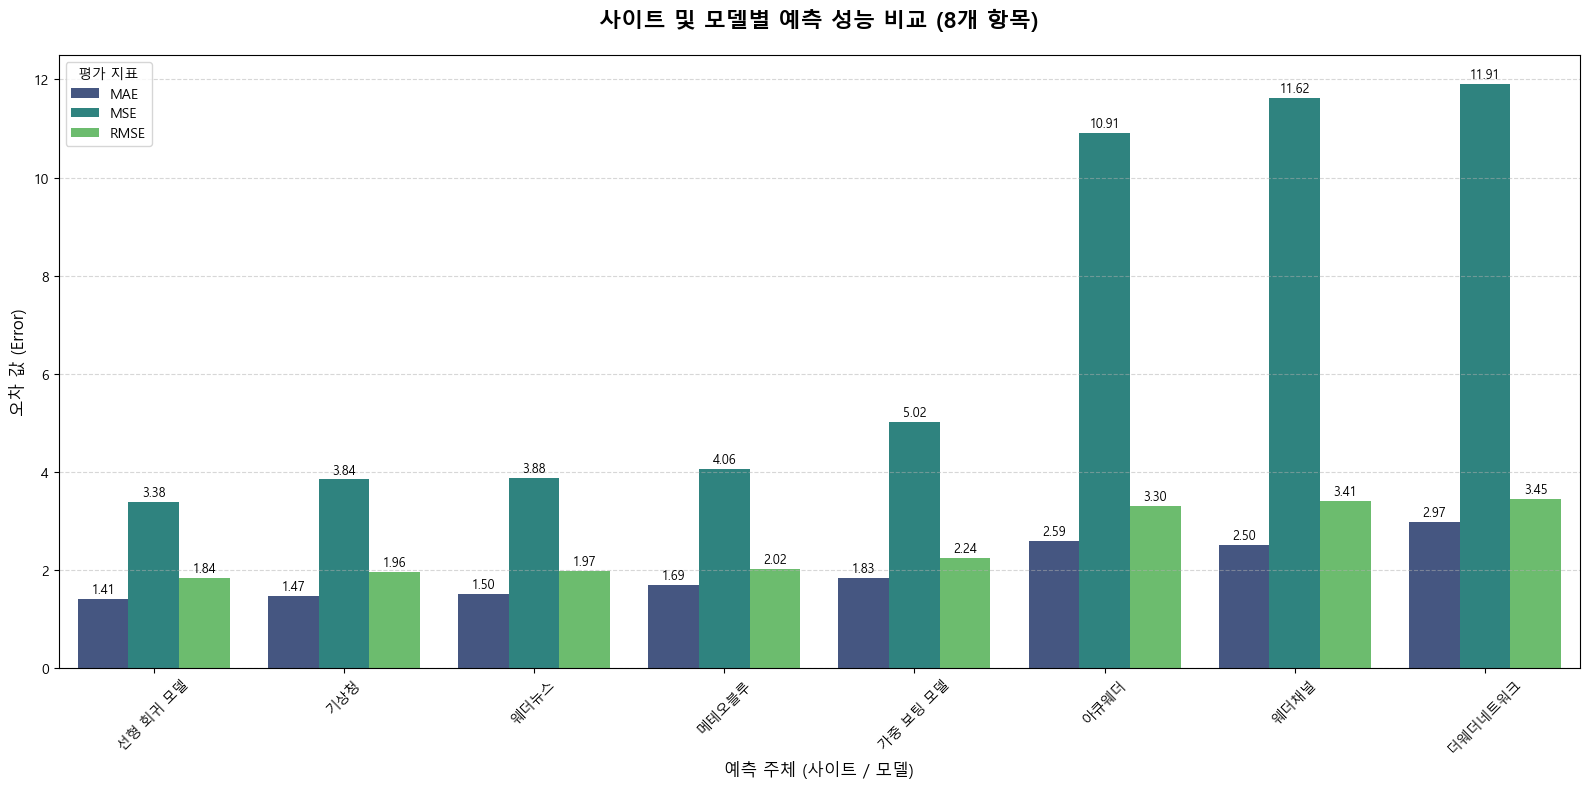

,Site,MAE,MSE,RMSE
6,선형 회귀 모델,1.411232,3.382170,1.839068
0,기상청,1.468750,3.843750,1.960548
4,웨더뉴스,1.500000,3.875000,1.968502
2,메테오블루,1.687500,4.062500,2.015564
7,가중 보팅 모델,1.834209,5.017558,2.239991
3,아큐웨더,2.593750,10.906250,3.302461
5,웨더채널,2.500000,11.625000,3.409545
1,더웨더네트워크,2.968750,11.906250,3.450543


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.font_manager as fm

# -------------------------------------------------------
# [설정] 한글 폰트 (환경에 맞게 주석 해제)
plt.rc('font', family='Malgun Gothic') # Windows
# -------------------------------------------------------

# 1. 데이터 로드
df = pd.read_csv('weather_filtered_7days.csv', encoding='cp949')
# 2. 데이터 구조 변환 (최고/최저 통합)
# (1) 최고 기온
df_max = df.pivot_table(index=['Measure_Date', 'Target_Date'], columns='Site', values='Max_Temp').reset_index()
target_max = df.groupby(['Measure_Date', 'Target_Date'])['Target_Max'].first().reset_index()
df_max = pd.merge(df_max, target_max, on=['Measure_Date', 'Target_Date'])
df_max.rename(columns={'Target_Max': 'Target'}, inplace=True)

# (2) 최저 기온
df_min = df.pivot_table(index=['Measure_Date', 'Target_Date'], columns='Site', values='Min_Temp').reset_index()
target_min = df.groupby(['Measure_Date', 'Target_Date'])['Target_Min'].first().reset_index()
df_min = pd.merge(df_min, target_min, on=['Measure_Date', 'Target_Date'])
df_min.rename(columns={'Target_Min': 'Target'}, inplace=True)

# (3) 통합
df_ensemble = pd.concat([df_max, df_min], axis=0).reset_index(drop=True)
df_ensemble.dropna(inplace=True)

# 3. 데이터 분할
sites = [col for col in df_ensemble.columns if col not in ['Measure_Date', 'Target_Date', 'Target']]
X = df_ensemble[sites]
y = df_ensemble['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 모델 구현 ---

# [모델 1] 선형 회귀 (Linear Regression)
# 오차(MSE)를 최소화하는 계수를 학습 (Bias 보정 포함)
lr_model = LinearRegression(fit_intercept=True)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# [모델 2] 가중 보팅 (Weighted Voting based on Inverse RMSE)
# 학습 데이터에서의 성능(RMSE)을 기반으로, 에러가 적은 사이트에 가중치를 더 줌
train_rmses = []
for site in sites:
    rmse = np.sqrt(mean_squared_error(y_train, X_train[site]))
    train_rmses.append(rmse)

train_rmses = np.array(train_rmses)
# 가중치 계산: 오차의 역수 (오차가 클수록 가중치 작게)
weights = 1 / train_rmses
weights /= weights.sum() # 가중치 합이 1이 되도록 정규화

# --- [수정된 부분] ---
# y_test가 정수일 수 있으므로, 실수형(float)으로 명시하여 0으로 채운 배열 생성
wv_pred = np.zeros_like(y_test, dtype=float)
# --------------------

for i, site in enumerate(sites):
    wv_pred += X_test[site].values * weights[i]

# --- 성능 평가 ---
def get_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {'Site': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse}

results = []

# 1. 개별 사이트 평가
for site in sites:
    results.append(get_metrics(site, y_test, X_test[site]))

# 2. 모델 평가 추가
results.append(get_metrics('선형 회귀 모델', y_test, lr_pred))
results.append(get_metrics('가중 보팅 모델', y_test, wv_pred))

# 데이터프레임 변환
df_res = pd.DataFrame(results)
# RMSE 순으로 정렬 (보기 좋게)
df_res = df_res.sort_values(by='RMSE')

# --- 시각화 데이터 변환 (Wide -> Long) ---
# seaborn barplot에서 hue를 쓰기 위해 데이터 형태 변경
df_melt = df_res.melt(id_vars='Site', value_vars=['MAE', 'MSE', 'RMSE'], 
                      var_name='Metric', value_name='Value')

# --- 그래프 그리기 ---
plt.figure(figsize=(16, 8))

# 막대 그래프 (x=사이트, y=값, hue=지표)
ax = sns.barplot(
    data=df_melt, 
    x='Site', 
    y='Value', 
    hue='Metric', 
    palette='viridis' # 색상 테마: viridis, deep, pastel 등 변경 가능
)

# 디자인 및 수치 표시
plt.title('사이트 및 모델별 예측 성능 비교 (8개 항목)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('예측 주체 (사이트 / 모델)', fontsize=12)
plt.ylabel('오차 값 (Error)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='평가 지표')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 막대 위에 수치 표시 (가독성을 위해 글자 크기 조정)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f'{p.get_height():.2f}', 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='bottom', 
            fontsize=9, color='black', 
            xytext=(0, 2), textcoords='offset points'
        )

plt.tight_layout()
plt.savefig('last_png.png')
plt.show()

# 결과 텍스트 출력
df_res